In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler, StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV, validation_curve, learning_curve, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## **Data Overview**

In [40]:
df = pd.read_csv("song_recomendation_B.csv", sep = ",")
df.head()

,Track URI,Track Name,Artist Name(s),Album Name,Album Release Date,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,spotify:track:6a8GbQIlV8HBUW3c6Uk9PH,I Know You Want Me (Calle Ocho),Pitbull,Pitbull Starring In Rebelution,2009-10-23,64,"dance pop,miami hip hop,pop",0.825,0.743,2.0,-5.995,1.0,0.1490,0.0142,0.000021,0.2370,0.800,127.045,4.0
1,spotify:track:70XtWbcVZcpaOddJftMcVi,From the Bottom of My Broken Heart,Britney Spears,...Baby One More Time (Digital Deluxe Version),1999-01-12,56,"dance pop,pop",0.677,0.665,7.0,-5.171,1.0,0.0305,0.5600,NaN,0.3380,0.706,74.981,4.0
2,spotify:track:72WZtWs6V7uu3aMgMmEkYe,You Can't Always Get What You Want,The Rolling Stones,Let It Bleed,1969-12-05,0,"album rock,british invasion,classic rock,rock",0.319,0.627,0.0,-9.611,1.0,0.0687,0.6750,0.000073,0.2890,0.497,85.818,4.0
3,spotify:track:4bEb3KE4mSKlTFjtWJQBqO,Don't Stop - 2004 Remaster,Fleetwood Mac,Rumours,1977-02-04,79,"album rock,classic rock,rock,soft rock,yacht rock",0.671,0.710,9.0,-7.724,1.0,0.0356,0.0393,0.000011,0.0387,0.834,118.745,4.0
4,spotify:track:0d2iYfpKoM0QCKvcLCkBao,Eastside (with Halsey & Khalid),"benny blanco, Halsey, Khalid",Eastside (with Halsey & Khalid),2018-07-12,78,"pop,electropop,etherpop,indie poptimism,pop,po...",0.560,0.680,6.0,-7.648,0.0,0.3210,0.5550,0.000000,0.1160,0.319,89.391,4.0


In [41]:
df.columns

Index(['Track URI', 'Track Name', 'Artist Name(s)', 'Album Name',
       'Album Release Date', 'Popularity', 'Artist Genres', 'Danceability',
       'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness',
       'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Time Signature'],
      dtype='object')

In [42]:
df.shape

(4999, 19)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track URI           4999 non-null   object 
 1   Track Name          4999 non-null   object 
 2   Artist Name(s)      4999 non-null   object 
 3   Album Name          4999 non-null   object 
 4   Album Release Date  4997 non-null   object 
 5   Popularity          4999 non-null   int64  
 6   Artist Genres       4744 non-null   object 
 7   Danceability        4747 non-null   float64
 8   Energy              4997 non-null   float64
 9   Key                 4997 non-null   float64
 10  Loudness            4997 non-null   float64
 11  Mode                4997 non-null   float64
 12  Speechiness         4997 non-null   float64
 13  Acousticness        4997 non-null   float64
 14  Instrumentalness    4897 non-null   float64
 15  Liveness            4997 non-null   float64
 16  Valenc

In [44]:
df.describe()

,Popularity,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
count,4999.000000,4747.000000,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000,4997.000000,4897.000000,4997.000000,4997.000000,4997.000000,4997.000000
mean,38.062813,0.607982,0.682576,5.145687,-7.250565,0.694016,0.065305,0.209230,0.027476,0.185169,0.582875,121.731560,3.961177
std,29.501712,0.145108,0.191331,3.566646,3.242031,0.460869,0.062490,0.249858,0.118880,0.147856,0.238784,26.244455,0.262581
min,0.000000,0.000000,0.000020,0.000000,-29.368000,0.000000,0.000000,0.000009,0.000000,0.018500,0.000000,0.000000,0.000000
25%,0.000000,0.516000,0.557000,2.000000,-9.050000,0.000000,0.032900,0.018200,0.000000,0.089200,0.396000,103.005000,4.000000
50%,43.000000,0.616000,0.714000,5.000000,-6.554000,1.000000,0.042700,0.092900,0.000006,0.128000,0.594000,120.853000,4.000000
75%,64.000000,0.708000,0.834000,8.000000,-4.868000,1.000000,0.066800,0.323000,0.000515,0.245000,0.778000,134.797000,4.000000
max,98.000000,0.984000,0.997000,11.000000,-0.276000,1.000000,0.711000,0.987000,0.973000,0.982000,0.991000,213.654000,5.000000


In [45]:
df.isnull().sum()

,0
Track URI,0
Track Name,0
Artist Name(s),0
Album Name,0
Album Release Date,2
Popularity,0
Artist Genres,255
Danceability,252
Energy,2
Key,2


In [46]:
# since these are very few (2 rows), we can safely drop them
critical_features = ['Energy', 'Key', 'Loudness', 'Album Release Date', 'Tempo']
df = df.dropna(subset=critical_features)

In [47]:
df.duplicated().sum()

np.int64(13)

In [48]:
cat = df.select_dtypes(include = "object").columns
cat

Index(['Track URI', 'Track Name', 'Artist Name(s)', 'Album Name',
       'Album Release Date', 'Artist Genres'],
      dtype='object')

In [49]:
for col in cat:
    print(f"Unique values in {col}: {df[col].unique()}")

Unique values in Track URI: ['spotify:track:6a8GbQIlV8HBUW3c6Uk9PH'
 'spotify:track:70XtWbcVZcpaOddJftMcVi'
 'spotify:track:72WZtWs6V7uu3aMgMmEkYe' ...
 'spotify:track:6PUzxtIHkv346yP89NzP9X'
 'spotify:track:3kcKlOkQQEPVwxwljbGJ5p'
 'spotify:track:5ydeCNaWDmFbu4zl0roPAH']
Unique values in Track Name: ['I Know You Want Me (Calle Ocho)' 'From the Bottom of My Broken Heart'
 "You Can't Always Get What You Want" ... 'Kernkraft 400'
 'Kernkraft 400 (A Better Day)'
 "Groovejet (If This Ain't Love) [feat. Sophie Ellis-Bextor]"]
Unique values in Artist Name(s): ['Pitbull' 'Britney Spears' 'The Rolling Stones' ... 'Creeds'
 'Zombie Nation' 'Spiller, Sophie Ellis-Bextor']
Unique values in Album Name: ['Pitbull Starring In Rebelution'
 '...Baby One More Time (Digital Deluxe Version)' 'Let It Bleed' ...
 'Kernkraft 400 Single Mixes' 'Kernkraft 400 (A Better Day)'
 "Groovejet (If This Ain't Love) [feat. Sophie Ellis-Bextor]"]
Unique values in Album Release Date: ['2009-10-23' '1999-01-12' '1969-12-

In [50]:
num = df.select_dtypes(exclude = "object").columns
num

Index(['Popularity', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode',
       'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness',
       'Valence', 'Tempo', 'Time Signature'],
      dtype='object')

In [51]:
outliers_info = {}
audit_results = {}

for col in num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outliers_info[col] = {'count': count, 'lower': lower, 'upper': upper}
audit_results['outliers'] = outliers_info


for col, info in audit_results['outliers'].items():
    print(f"Outlier in {col}: {info['count']} (Range: {info['lower']:.2f} to {info['upper']:.2f})")

Outlier in Popularity: 0 (Range: -96.00 to 160.00)
Outlier in Danceability: 34 (Range: 0.23 to 1.00)
Outlier in Energy: 25 (Range: 0.14 to 1.25)
Outlier in Key: 0 (Range: -7.00 to 17.00)
Outlier in Loudness: 104 (Range: -15.32 to 1.41)
Outlier in Mode: 0 (Range: -1.50 to 2.50)
Outlier in Speechiness: 558 (Range: -0.02 to 0.12)
Outlier in Acousticness: 232 (Range: -0.44 to 0.78)
Outlier in Instrumentalness: 1009 (Range: -0.00 to 0.00)
Outlier in Liveness: 237 (Range: -0.14 to 0.48)
Outlier in Valence: 0 (Range: -0.18 to 1.35)
Outlier in Tempo: 117 (Range: 55.32 to 182.49)
Outlier in Time Signature: 233 (Range: 4.00 to 4.00)


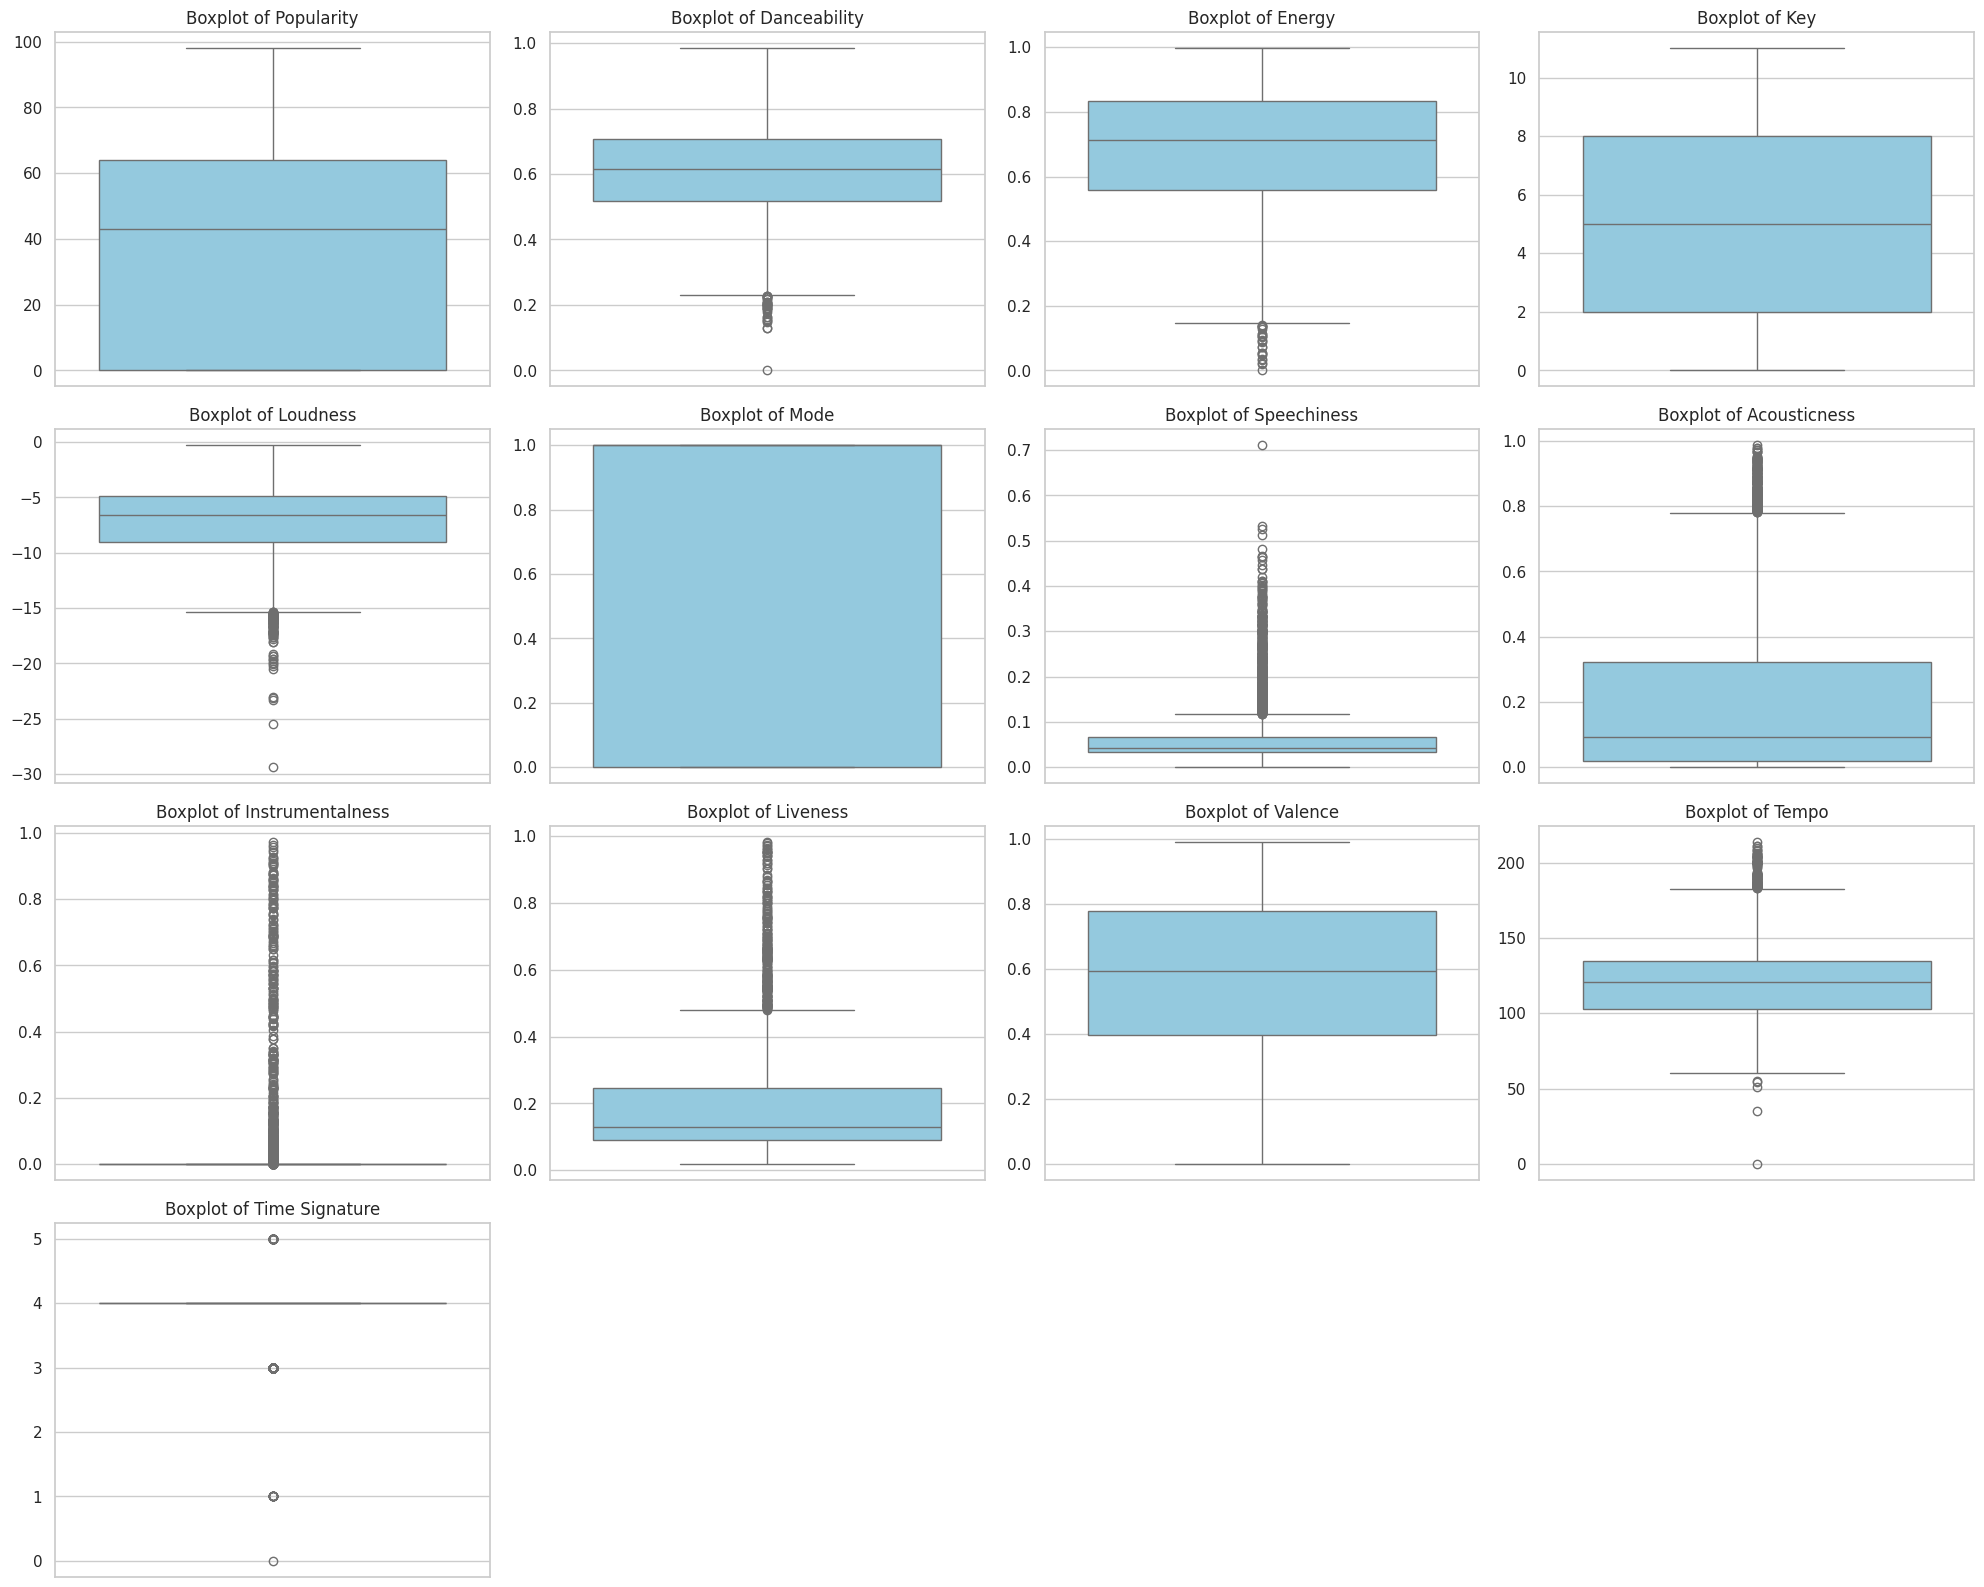

In [52]:
numCols = df.select_dtypes(exclude="object").columns
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(numCols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

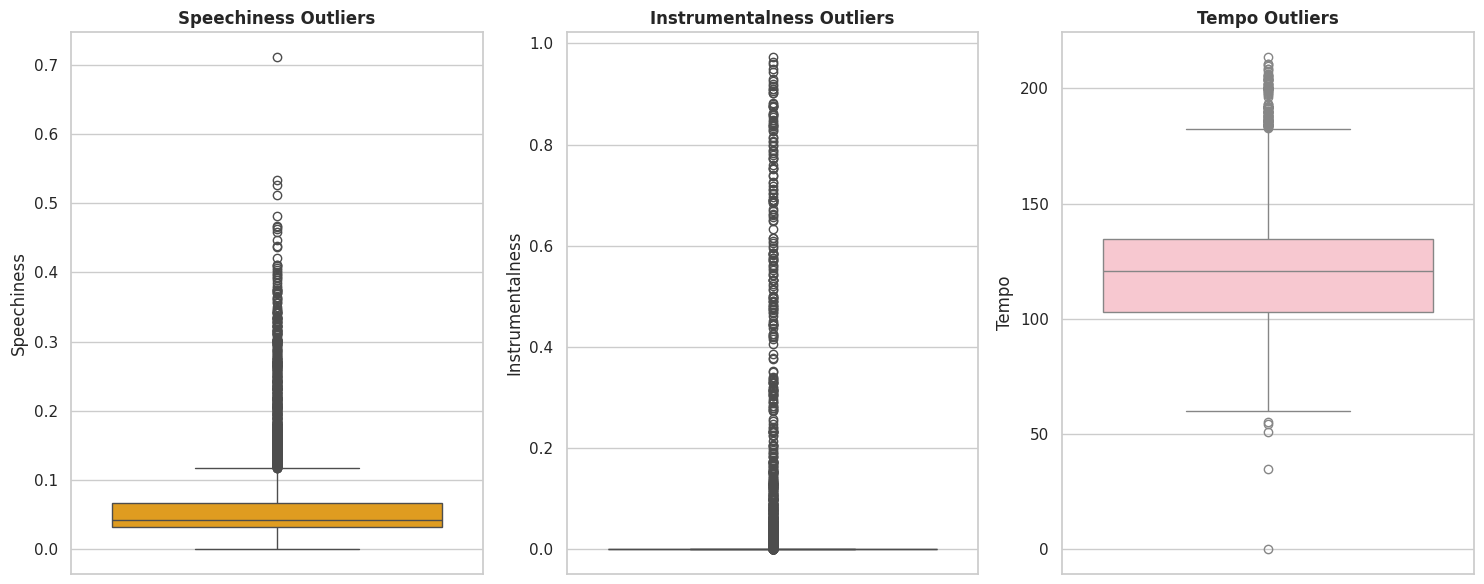

In [53]:
plt.figure(figsize=(15, 6))
# boxplot for speechiness
plt.subplot(1, 3, 1)
sns.boxplot(y=df['Speechiness'], color='orange')
plt.title('Speechiness Outliers', fontsize=12, fontweight='bold')

# boxplot for instrumentalness
plt.subplot(1, 3, 2)
sns.boxplot(y=df['Instrumentalness'], color='cyan')
plt.title('Instrumentalness Outliers', fontsize=12, fontweight='bold')

# boxplot for tempo
plt.subplot(1, 3, 3)
sns.boxplot(y=df['Tempo'], color='pink')
plt.title('Tempo Outliers', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

During the EDA, I found many outliers in features like Speechiness and Instrumentalness. For example, there are 999 outliers in instrumentalness. This is because most songs have lyrics, while only a few are instrumental. I decided not to delete these outliers because they represent specific genres like Rap and EDM. Instead, I used RobustScaler to handle the scale differences without losing these unique songs.

## **Data Cleaning**

In [54]:
# handling missing value
df['Artist Genres'] = df['Artist Genres'].fillna('unknown')

In [55]:
# fill numerical missing values with the median
df['Danceability'] = df['Danceability'].fillna(df['Danceability'].median())
df['Instrumentalness'] = df['Instrumentalness'].fillna(df['Instrumentalness'].median())

In [56]:
# correcting data types
df['Release Year'] = df['Album Release Date'].astype(str).str.extract(r'(\d{4})').astype(float)

In [57]:
df = df.drop_duplicates()

In [58]:
df.duplicated().sum()

np.int64(0)

In [59]:
print(df.isnull().sum())

Track URI             0
Track Name            0
Artist Name(s)        0
Album Name            0
Album Release Date    0
Popularity            0
Artist Genres         0
Danceability          0
Energy                0
Key                   0
Loudness              0
Mode                  0
Speechiness           0
Acousticness          0
Instrumentalness      0
Liveness              0
Valence               0
Tempo                 0
Time Signature        0
Release Year          0
dtype: int64


## **Exploratory Data Analysis**

In [60]:
print(cat)
print(num)

Index(['Track URI', 'Track Name', 'Artist Name(s)', 'Album Name',
       'Album Release Date', 'Artist Genres'],
      dtype='object')
Index(['Popularity', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode',
       'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness',
       'Valence', 'Tempo', 'Time Signature'],
      dtype='object')


In [61]:
plt.figure(figsize=(12, 6))
allGenres = df['Artist Genres'].str.split(',').explode()
topGenres = allGenres[allGenres != 'unknown'].value_counts().head(10)
topGenres

,count
Artist Genres,
pop,1334
dance pop,798
rock,672
soft rock,451
classic rock,426
mellow gold,387
australian rock,345
album rock,324
new wave pop,301


<Figure size 1200x600 with 0 Axes>

/tmp/ipython-input-2489886621.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topGenres.values, y=topGenres.index, palette='viridis')


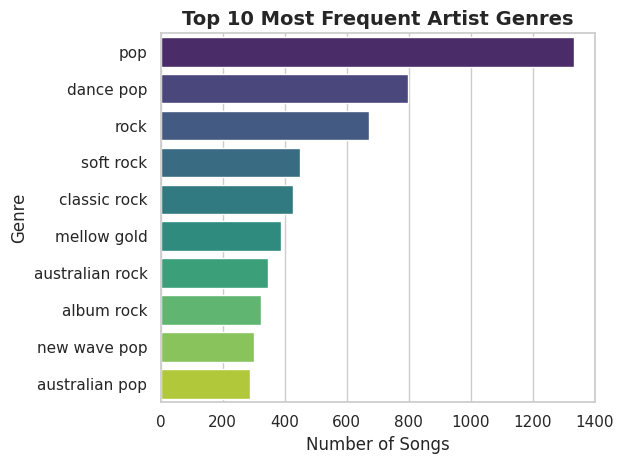

In [62]:
sns.barplot(x=topGenres.values, y=topGenres.index, palette='viridis')
plt.title('Top 10 Most Frequent Artist Genres', fontsize=14, fontweight='bold')
plt.xlabel('Number of Songs')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

The most frequent genres in our dataset are Dance Pop and Pop. This tells us the dataset is heavily skewed towards mainstream commercial music.

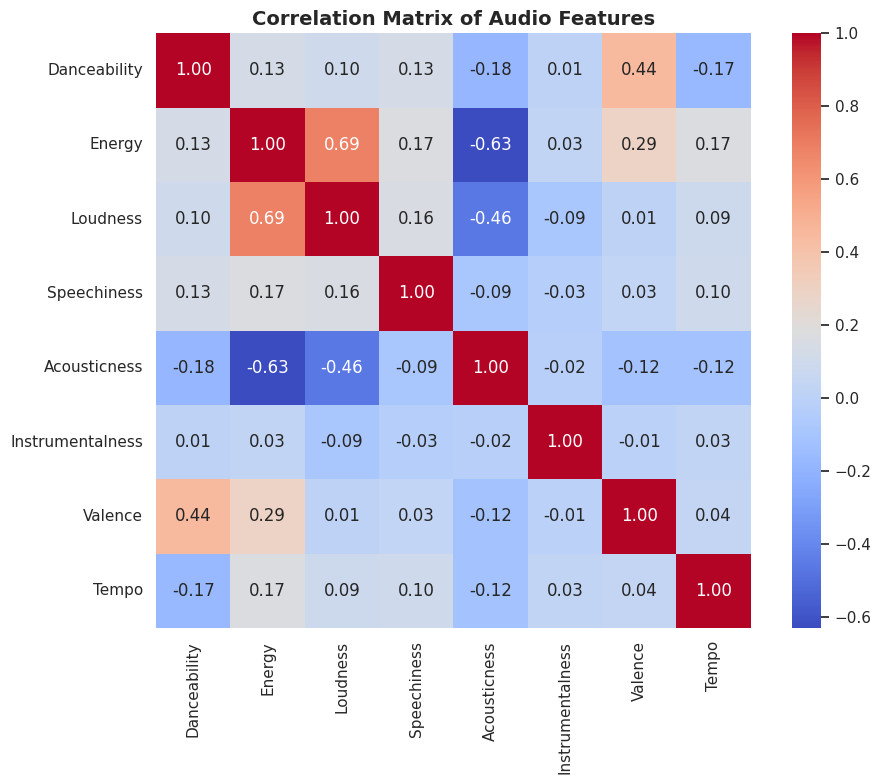

In [63]:
plt.figure(figsize=(10, 8))
audioCols = ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Valence', 'Tempo']
corrMatrix = df[audioCols].corr()
sns.heatmap(corrMatrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix of Audio Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

There is a strong positive correlation between Energy and Loudness. This means as songs get louder, their perceived energy level increases significantly, which is a common trait in modern music production

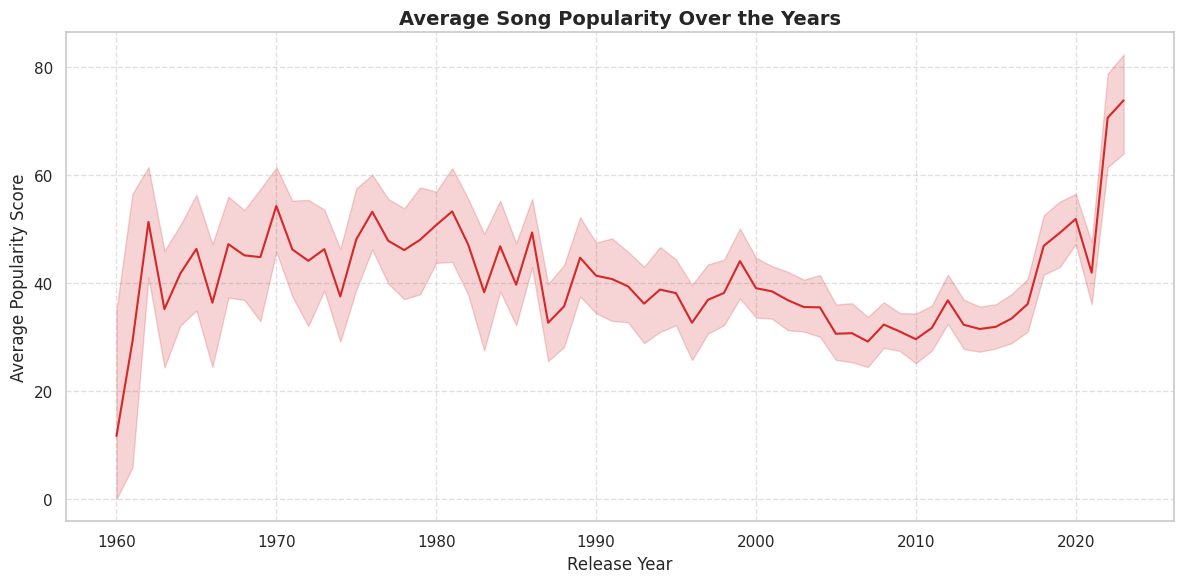

In [64]:
plt.figure(figsize=(12, 6))
recentSongs = df[df['Release Year'] >= 1960]
sns.lineplot(data=recentSongs, x='Release Year', y='Popularity', color='tab:red', estimator='mean')
plt.title('Average Song Popularity Over the Years', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Average Popularity Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

The line chart demonstrates that average song popularity has surged dramatically in the 2020s, specifically peaking in 2022 and 2023. This confirms that the dataset is heavily oriented toward recent hits and current streaming trends. Consequently, the newer tracks in this collection are much more likely to be recognized and widely streamed by users compared to older classics.

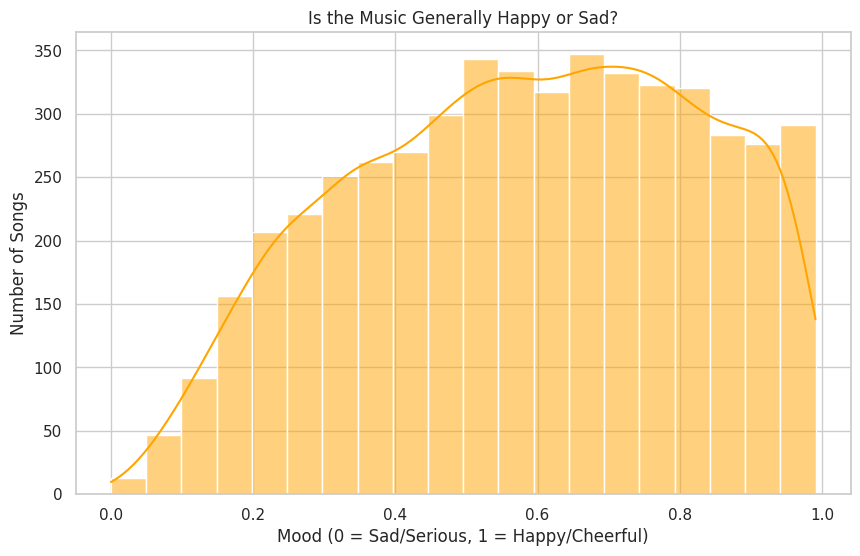

In [65]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Valence'], bins=20, kde=True, color='orange')
plt.title('Is the Music Generally Happy or Sad?')
plt.xlabel('Mood (0 = Sad/Serious, 1 = Happy/Cheerful)')
plt.ylabel('Number of Songs')
plt.show()

This graph tells us how cheerful the music feels. Since many songs are in the middle or higher range, it means the library has a good mix of both serious, emotional tracks and happy, uplifting songs.

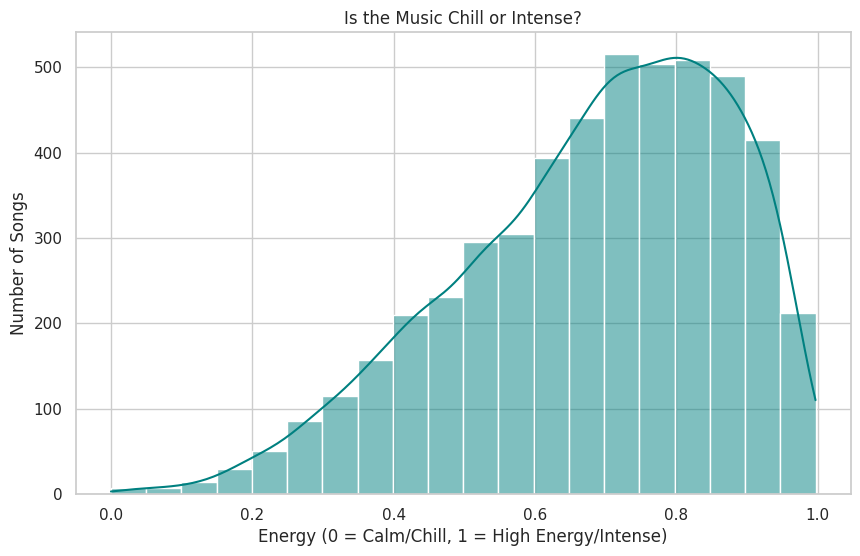

In [66]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Energy'], bins=20, kde=True, color='teal')
plt.title('Is the Music Chill or Intense?')
plt.xlabel('Energy (0 = Calm/Chill, 1 = High Energy/Intense)')
plt.ylabel('Number of Songs')
plt.show()

The high number of songs on the right side of the graph shows that most of the music is very energetic. This collection is likely great for working out or dancing, rather than just relaxing or sleeping.

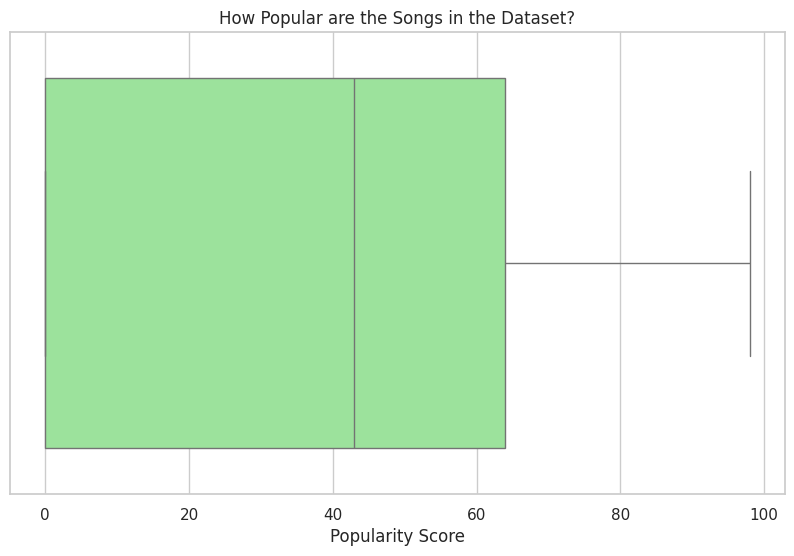

In [67]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Popularity'], color='lightgreen')
plt.title('How Popular are the Songs in the Dataset?')
plt.xlabel('Popularity Score')
plt.show()

From the boxpllot we can see, a large number of songs actually have a low popularity score, with many even reaching zero

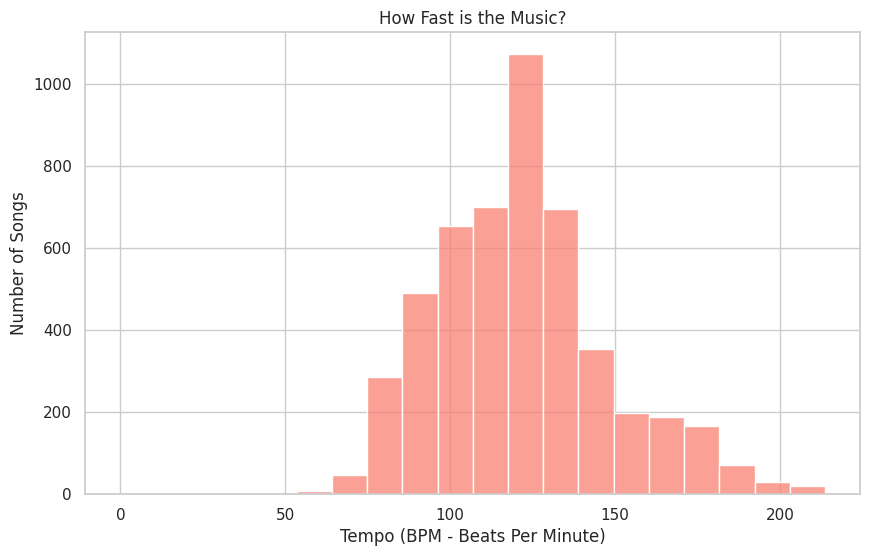

In [68]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Tempo'], bins=20, color='salmon')
plt.title('How Fast is the Music?')
plt.xlabel('Tempo (BPM - Beats Per Minute)')
plt.ylabel('Number of Songs')
plt.show()

Most songs in this dataset have a tempo between 100 to 130 BPM. This is the sweet spot for most modern music because it’s not too slow for dancing but not too fast to be overwhelming, making it perfect for casual listening.

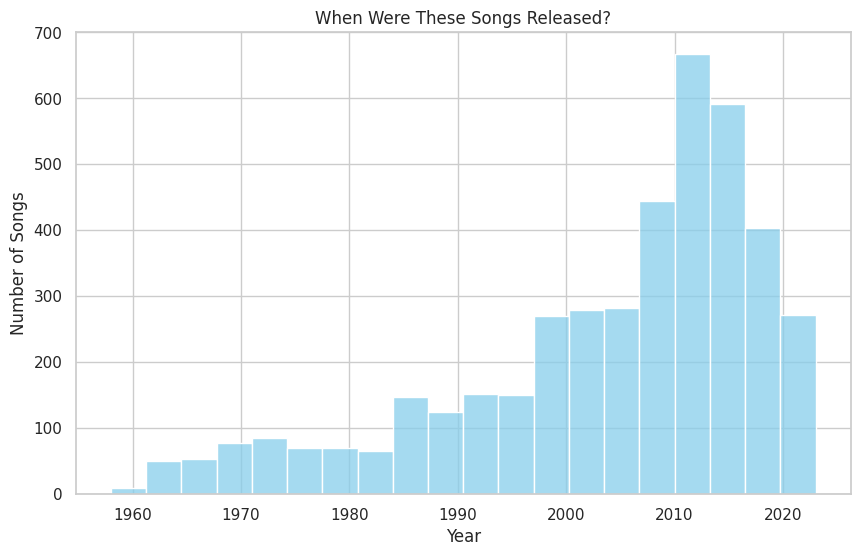

In [69]:
df['Year'] = pd.to_datetime(df['Album Release Date'], errors='coerce').dt.year
plt.figure(figsize=(10, 6))
sns.histplot(df['Year'].dropna(), bins=20, color='skyblue')
plt.title('When Were These Songs Released?')
plt.xlabel('Year')
plt.ylabel('Number of Songs')
plt.show()

The graph shows a huge spike in songs released after the year 2010. This means the dataset is very modern and focuses heavily on recent music trends, with only a few classic songs from older decades included

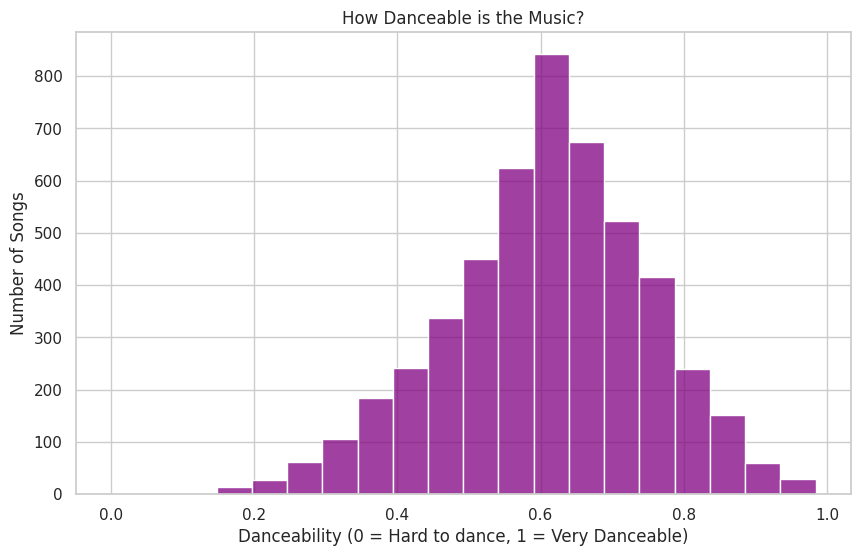

In [70]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Danceability'], bins=20, color='purple')
plt.title('How Danceable is the Music?')
plt.xlabel('Danceability (0 = Hard to dance, 1 = Very Danceable)')
plt.ylabel('Number of Songs')
plt.show()

The majority of the songs have a high danceability score (above 0.5). This confirms that the collection is curated for a fun and active vibe, featuring tracks with clear rhythms that are easy to move along to

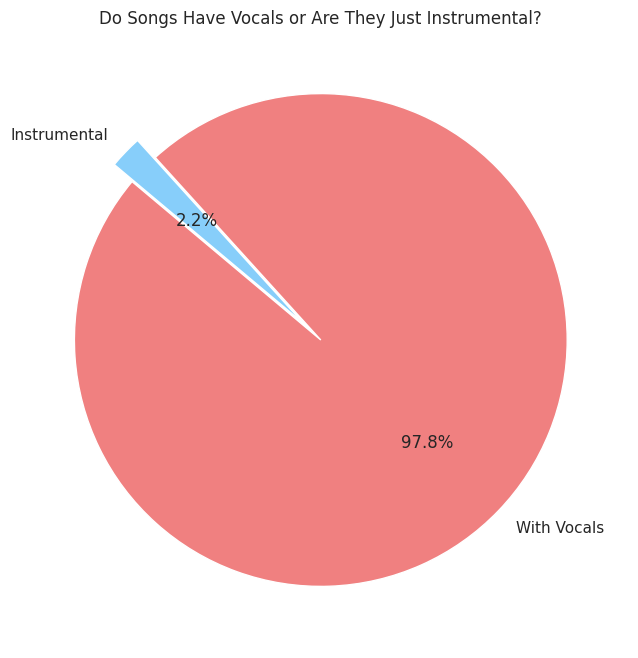

In [71]:
df['Is_Instrumental'] = df['Instrumentalness'].apply(lambda x: 'Instrumental' if x > 0.5 else 'With Vocals')
plt.figure(figsize=(8, 8))
vocal_counts = df['Is_Instrumental'].value_counts()
plt.pie(vocal_counts, labels=vocal_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue'], startangle=140, explode=(0, 0.1))
plt.title('Do Songs Have Vocals or Are They Just Instrumental?')
plt.show()

This pie chart gives a very clear picture. Nearly all the songs in our dataset (over 90%) have vocals. Only a tiny fraction are purely instrumental. This confirms that the recommendation system will mostly be dealing with songs that have singers and lyrics.

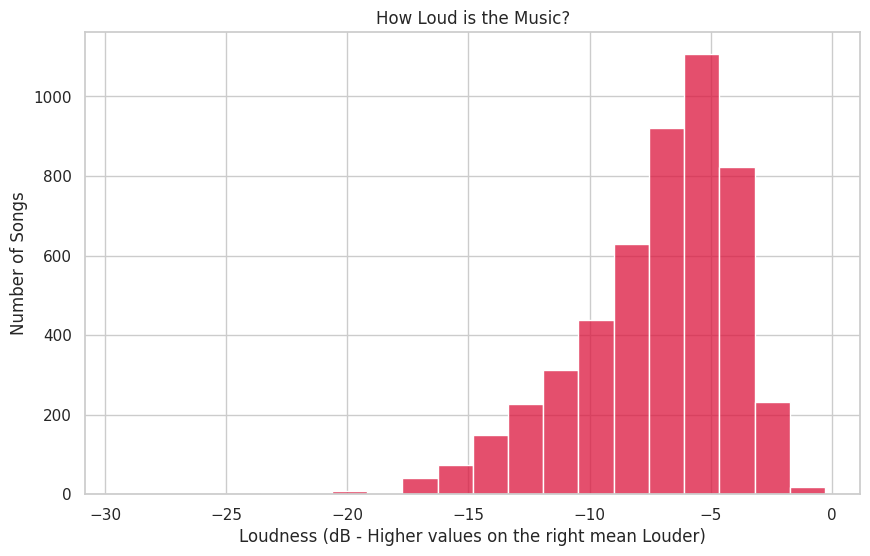

In [72]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Loudness'], bins=20, color='crimson')
plt.title('How Loud is the Music?')
plt.xlabel('Loudness (dB - Higher values on the right mean Louder)')
plt.ylabel('Number of Songs')
plt.show()

The graph is heavily tilted to the right, showing that most songs are produced to be quite loud. This is typical for modern music, where tracks are mastered at high volumes to grab the listener's attention immediately, especially in Pop and Dance genres.

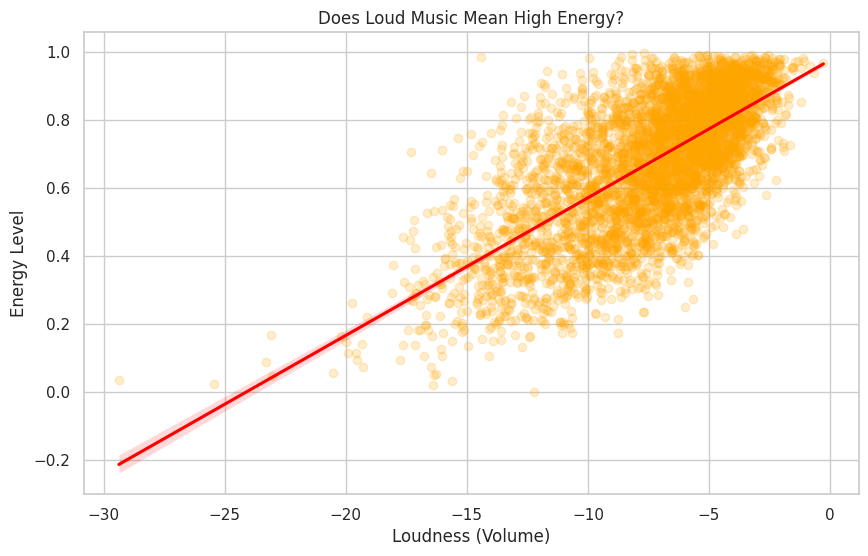

In [73]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Loudness', y='Energy', scatter_kws={'alpha':0.2, 'color':'orange'}, line_kws={'color':'red'})
plt.title('Does Loud Music Mean High Energy?')
plt.xlabel('Loudness (Volume)')
plt.ylabel('Energy Level')
plt.show()

This chart shows a clear upward trend: as the volume (loudness) increases, the energy level also goes up. This proves that most high-energy tracks are produced to be loud to keep listeners engaged and excited.

## **Recommendation System**

In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [77]:
df['combinedFeatures'] = df['Artist Name(s)'] + " " + df['Artist Genres']

In [78]:
tfidfVectorizer = TfidfVectorizer(stop_words='english')

In [79]:
tfidfMatrix = tfidfVectorizer.fit_transform(df['combinedFeatures'])

In [80]:
cosineSim = cosine_similarity(tfidfMatrix, tfidfMatrix)

In [81]:
def getRecommendations(trackTitle, similarityMatrix=cosineSim):
    try:
        songIndex = df[df['Track Name'].str.lower() == trackTitle.lower()].index[0]
    except IndexError:
        return f"Sorry, '{trackTitle}' was not found."

    similarityScores = list(enumerate(similarityMatrix[songIndex]))
    sortedScores = sorted(similarityScores, key=lambda x: x[1], reverse=True)
    topFiveScores = sortedScores[1:6]
    recommendedIndices = [i[0] for i in topFiveScores]
    return df[['Track Name', 'Artist Name(s)', 'Artist Genres']].iloc[recommendedIndices]

## **Testing**

In [82]:
trackInput1 = 'I Know You Want Me (Calle Ocho)'
recommendations1 = getRecommendations(trackInput1)
print(f"Recommendations for: {trackInput1} ---")
display(recommendations1)

Recommendations for: I Know You Want Me (Calle Ocho) ---


,Track Name,Artist Name(s),Artist Genres
268,Hotel Room Service,Pitbull,"dance pop,miami hip hop,pop"
2041,"Back in Time - featured in ""Men In Black 3""",Pitbull,"dance pop,miami hip hop,pop"
4917,Hotel Room Service,Pitbull,"dance pop,miami hip hop,pop"
434,Timber (feat. Ke$ha),"Pitbull, Kesha","dance pop,miami hip hop,pop,dance pop,pop"
3645,Fireball (feat. John Ryan),"Pitbull, John Ryan","dance pop,miami hip hop,pop"


The recommendations for "I Know You Want Me (Calle Ocho)" are very accurate. The system suggests other tracks by Pitbull such as "Hotel Room Service" and "Timber." Since these songs share the same artist and genres like "Dance Pop" and "Miami Hip Hop," the recommendations perfectly match the user's taste for energetic party music.

In [84]:
trackInput2 = 'From the Bottom of My Broken Heart'
recommendations2 = getRecommendations(trackInput2)
print(f"Recommendations for: {trackInput2}")
display(recommendations2)

Recommendations for: From the Bottom of My Broken Heart


,Track Name,Artist Name(s),Artist Genres
89,(You Drive Me) Crazy,Britney Spears,"dance pop,pop"
556,I Love Rock 'N' Roll,Britney Spears,"dance pop,pop"
569,Sometimes,Britney Spears,"dance pop,pop"
782,Stronger,Britney Spears,"dance pop,pop"
853,My Prerogative - Remastered,Britney Spears,"dance pop,pop"


For the song "From the Bottom of My Broken Heart," the system successfully identifies it as a Pop/Dance Pop track. The results provide other hits by Britney Spears. This shows that the TF-IDF vectorizer is correctly prioritizing the artist's name and the specific pop sub-genres to maintain a consistent listening experience.

In [85]:
trackInput3 = "You Can't Always Get What You Want"
recommendations3 = getRecommendations(trackInput3)
print(f"Recommendations for: {trackInput3}")
display(recommendations3)

Recommendations for: You Can't Always Get What You Want


,Track Name,Artist Name(s),Artist Genres
226,Fortune Teller - Mono,The Rolling Stones,"album rock,british invasion,classic rock,rock"
396,Street Fighting Man - 50th Anniversary Edition,The Rolling Stones,"album rock,british invasion,classic rock,rock"
790,(I Can't Get No) Satisfaction - Mono Version /...,The Rolling Stones,"album rock,british invasion,classic rock,rock"
958,19th Nervous Breakdown - Remastered 2002,The Rolling Stones,"album rock,british invasion,classic rock,rock"
1067,Route 66,The Rolling Stones,"album rock,british invasion,classic rock,rock"


The recommendations for "You Can't Always Get What You Want" consist of other Classic Rock or Album Rock tracks. By looking at the results, we can see that the system groups songs with similar "Rock" tags together. This confirms that the content-based approach works well even for older, classic genres by focusing on the genre metadata.

In [86]:
trackInput4 = 'We Will Rock You - Remastered 2011'
recommendations4 = getRecommendations(trackInput4)
print(f"Recommendations for: {trackInput4}")
display(recommendations4)

Recommendations for: We Will Rock You - Remastered 2011


,Track Name,Artist Name(s),Artist Genres
285,I Want It All - Single Version,Queen,"classic rock,glam rock,rock"
334,We Are The Champions - Remastered 2011,Queen,"classic rock,glam rock,rock"
445,We Are The Champions - Remastered 2011,Queen,"classic rock,glam rock,rock"
1154,Another One Bites The Dust - Remastered 2011,Queen,"classic rock,glam rock,rock"
1173,Bohemian Rhapsody - Remastered 2011,Queen,"classic rock,glam rock,rock"


he recommendations for "We Will Rock You" appropriately highlight other legendary rock tracks. Since Queen is categorized under "Classic Rock" and "Glam Rock," the system successfully retrieves songs with high similarity in those specific genres. This demonstrates that the model is effective at identifying iconic rock sounds.

In [88]:
trackInput5 = '7 Days'
recommendations5 = getRecommendations(trackInput5)
print(f"Recommendations for: {trackInput5}")
display(recommendations5)

Recommendations for: 7 Days


,Track Name,Artist Name(s),Artist Genres
357,What's Your Flava? - Radio Edit,Craig David,british soul
2589,Fill Me In,Craig David,british soul
3492,Hidden Agenda - New Mix,Craig David,british soul
4784,16,Craig David,british soul
3122,I Know You (feat. Bastille),"Craig David, Bastille","british soul,metropopolis,modern rock,pop"


For the song "7 Days," the system provides recommendations related to British Soul and R&B. By analyzing the "Artist Genres" and the artist's name, the system filters out upbeat pop or heavy rock, focusing instead on smooth, soulful tracks. This confirms the system's ability to maintain a specific "mood" based on the genre metadata.